In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())


First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     39

In [3]:
X = df[['displacement']]
y = df['mpg']

print("Missing Values in ", X.isnull().sum())
print("Missing Values in mpg:", y.isnull().sum())

Missing Values in  displacement    0
dtype: int64
Missing Values in mpg: 0


In [4]:
data = df[['displacement', 'mpg']].dropna()

X = data[['displacement']]
y = data['mpg']

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 318
Testing samples: 80


In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MSE:", mse_linear)
print("R-Squared:", r2_linear)

Linear Regression Results
-------------------------
MSE: 18.102543998358946
R-Squared: 0.6633114869465596


In [7]:
results = []

polynomial_models = {}

results.append({
    'Model': 'Linear Regression',
    'Degree':1,
    'MSE': mse_linear,
    'R_squared': r2_linear
})

In [8]:
results = []
polynomial_models = {}

results.append({
    'Model': 'Linear Regression',
    'Degree': 1,
    'MSE': mse_linear,
    'R_squared': r2_linear
})

for degree in range(2, 6):

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()

    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R_squared': r2
    })

    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

results_df = pd.DataFrame(results)

results_df

,Model,Degree,MSE,R_squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,16.369649,0.695542
3,Polynomial Regression,4,18.398790,0.657802
4,Polynomial Regression,5,20.998146,0.609456


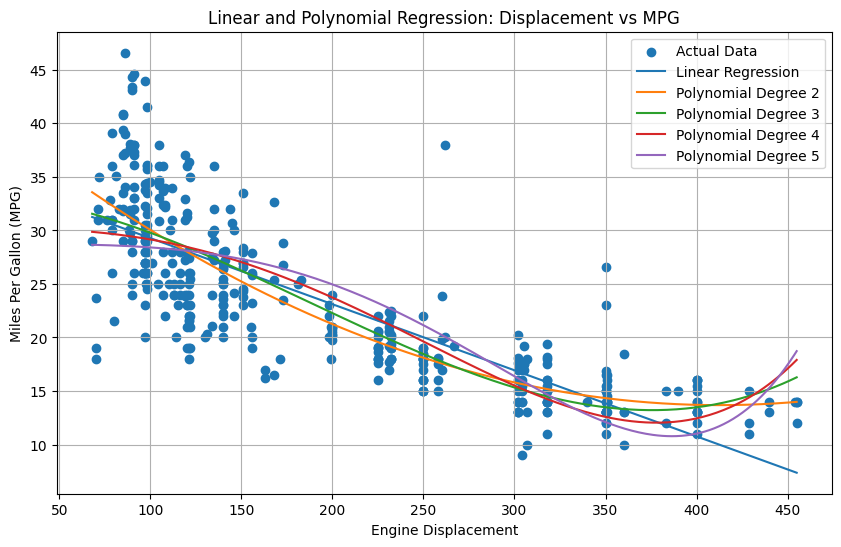

In [9]:
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

plt.figure(figsize=(10, 6))

plt.scatter(
    X['displacement'],
    y,
    label='Actual Data'
)

y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)

for degree in range(2, 6):
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    X_plot_poly = poly.transform(X_plot)

    y_plot_poly = poly_model.predict(X_plot_poly)

    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}'
    )

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')

plt.title(
    'Linear and Polynomial Regression: Displacement vs MPG'
)

plt.legend()
plt.grid(True)
plt.show()